# Value Function Approximation

In tabular reinforcement learning, every state (or state-action pair) has its own stored value. Function approximation replaces that table with a parameterised function:

$$V(s) \longrightarrow \hat v(s,\mathbf w), \qquad Q(s,a) \longrightarrow \hat q(s,a,\mathbf w).$$

Today we will move from one hand-computed update to policy evaluation on **FrozenLake-v1**, then to approximate control on the continuous-state **MountainCar-v0** environment.

**Learning objectives**

By the end, you should be able to:

1. explain why shared parameters produce generalisation;
2. derive and implement gradient Monte Carlo and semi-gradient TD(0);
3. distinguish Monte Carlo, TD, and $n$-step learning targets;
4. approximate action values for control with semi-gradient SARSA;
5. explain why nonlinear approximators and the deadly triad require care.

## 1. Why approximate a value function?

A table works when the state space is small. It becomes impractical when a state contains continuous quantities such as position, velocity, temperature, or an image.

Function approximation addresses four limitations of tables:

- **Scalability:** we store a fixed number of parameters instead of one value per possible state.
- **Memory:** the parameter vector can be much smaller than the state space.
- **Generalisation:** learning at one state can improve estimates at similar states.
- **Sample efficiency:** shared structure lets experience influence more than one table entry.

We first convert a state into features

$$\mathbf x(s)=[1,x_1(s),\ldots,x_d(s)]^\top,$$

and use the same parameter vector $\mathbf w$ for every state. For a linear approximator,

$$\hat v(s,\mathbf w)=\mathbf w^\top\mathbf x(s).$$

The approximator is linear in the **weights**; the features may still be nonlinear functions of the state.

In [1]:
# Run this cell only if Gymnasium is not already installed.
# try:
#     import gymnasium as gym
# except ImportError:
#     %pip install -q "gymnasium==1.2.1"
#     import gymnasium as gym

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display

SEED = 7
rng = np.random.default_rng(SEED)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (8, 4.5), "font.size": 11})

print("Gymnasium version:", gym.__version__)
print("Random seed:", SEED)

Gymnasium version: 1.3.0
Random seed: 7


## 2. One update: shared parameters create generalisation

Consider five states with features $\mathbf x(s_i)=[1,i/5]^\top$. Suppose

$$\mathbf w_0=[0.2,0.5]^\top,\quad G(s_3)=0.8,\quad \alpha=0.1.$$

The sample loss is

$$L_t(\mathbf w)=\frac12\left[U_t-\hat v(S_t,\mathbf w)\right]^2.$$

Stochastic gradient descent gives the general update

$$\mathbf w_{t+1}=\mathbf w_t+\alpha\left[U_t-\hat v(S_t,\mathbf w_t)\right]\nabla_{\mathbf w}\hat v(S_t,\mathbf w_t).$$

For a linear approximator, $\nabla_{\mathbf w}\hat v(s,\mathbf w)=\mathbf x(s)$, so

$$\mathbf w_{t+1}=\mathbf w_t+\alpha\left[U_t-\mathbf w_t^\top\mathbf x(S_t)\right]\mathbf x(S_t).$$

Before running the cell, predict which of the five state estimates will change.

x(s3)             = [1.  0.6]
Initial prediction = 0.500
Prediction error   = 0.300
Updated weights    = [0.23  0.518]


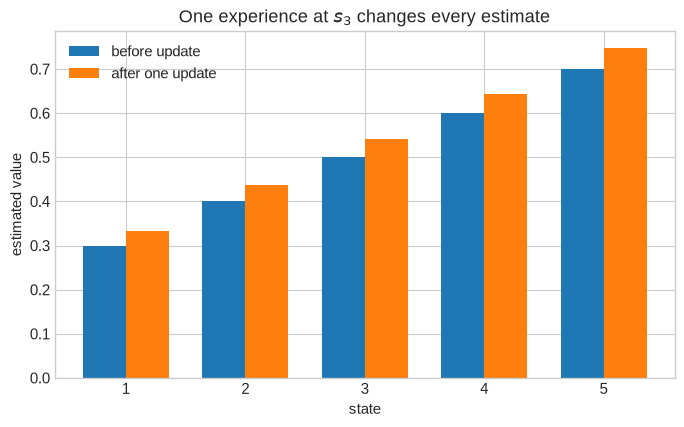

In [2]:
states = np.arange(1, 6)
X = np.column_stack([np.ones(5), states / 5])
w_before = np.array([0.2, 0.5])

x_s3 = X[2]
target = 0.8
alpha = 0.1
prediction = w_before @ x_s3
error = target - prediction
w_after = w_before + alpha * error * x_s3

values_before = X @ w_before
values_after = X @ w_after

print(f"x(s3)             = {x_s3}")
print(f"Initial prediction = {prediction:.3f}")
print(f"Prediction error   = {error:.3f}")
print(f"Updated weights    = {w_after}")

width = 0.36
fig, ax = plt.subplots()
ax.bar(states - width/2, values_before, width, label="before update")
ax.bar(states + width/2, values_after, width, label="after one update")
ax.set(xlabel="state", ylabel="estimated value", xticks=states,
       title="One experience at $s_3$ changes every estimate")
ax.legend()
plt.show()

In [3]:
X

array([[1. , 0.2],
       [1. , 0.4],
       [1. , 0.6],
       [1. , 0.8],
       [1. , 1. ]])

### What just happened?

Only $s_3$ produced an error, but every state uses the same two weights. Therefore all five predictions moved. This is **generalisation**.

Generalisation is useful only when the features encode a sensible notion of similarity. Poor features can force unrelated states to share updates and create **interference**.

The objective we would ideally minimise is the mean-squared value error

$$J(\mathbf w)=\mathbb E_{S\sim\mu}\left[(v_\pi(S)-\hat v(S,\mathbf w))^2\right],$$

where $\mu$ determines which states matter most. In practice $v_\pi$ is unknown, so experience supplies a target $U_t$.

| Method | Target $U_t$ | Available |
|---|---|---|
| Monte Carlo | $G_t$ | after the episode |
| TD(0) | $R_{t+1}+\gamma\hat v(S_{t+1},\mathbf w_t)$ | after one transition |
| $n$-step TD | $G_t^{(n)}$ | after $n$ transitions |

## 3. Gym example: evaluate a policy on FrozenLake

We use deterministic `FrozenLake-v1` so the mechanics are easy to see. The symbols are:

- `S`: start; `F`: safe frozen tile; `H`: hole; `G`: goal.
- actions: 0 = left, 1 = down, 2 = right, 3 = up.
- reward: 1 only on reaching the goal; otherwise 0.

Our policy follows a safe route most of the time but chooses a random action with probability $\varepsilon=0.1$. This ensures that multiple states are sampled.

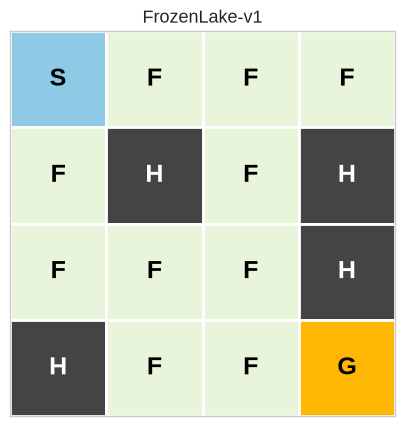

In [4]:
env = gym.make("FrozenLake-v1", is_slippery=False)
grid = np.asarray(env.unwrapped.desc, dtype="U1")
action_names = np.array(["left", "down", "right", "up"])

fig, ax = plt.subplots(figsize=(5, 5))
colors = {"S": "#8ecae6", "F": "#e9f5db", "H": "#444444", "G": "#ffb703"}
for r in range(4):
    for c in range(4):
        tile = grid[r, c]
        ax.add_patch(plt.Rectangle((c, 3-r), 1, 1, color=colors[tile], ec="white", lw=2))
        ax.text(c + .5, 3-r + .5, tile, ha="center", va="center",
                color="white" if tile == "H" else "black", fontsize=18, weight="bold")
ax.set(xlim=(0, 4), ylim=(0, 4), xticks=[], yticks=[], title="FrozenLake-v1")
ax.set_aspect("equal")
plt.show()

In [5]:
# Preferred action at each non-terminal state. The main route is
# 0 -> 4 -> 8 -> 9 -> 10 -> 14 -> 15.
preferred_action = np.array([
    1, 2, 1, 0,
    1, 0, 1, 0,
    2, 2, 1, 0,
    0, 2, 2, 0,
])

EPSILON = 0.10
N_ACTIONS = env.action_space.n

def policy_probabilities(state):
    probs = np.full(N_ACTIONS, EPSILON / N_ACTIONS)
    probs[preferred_action[state]] += 1.0 - EPSILON
    return probs

def sample_episode(env, rng):
    state, _ = env.reset(seed=int(rng.integers(1_000_000)))
    trajectory = []
    terminated = truncated = False
    while not (terminated or truncated):
        action = rng.choice(N_ACTIONS, p=policy_probabilities(state))
        next_state, reward, terminated, truncated, _ = env.step(action)
        trajectory.append((state, action, reward, next_state, terminated or truncated))
        state = next_state
    return trajectory

episode = sample_episode(env, rng)
print("states :", [step[0] for step in episode] + [episode[-1][3]])
print("actions:", [action_names[step[1]] for step in episode])
print("return :", sum(step[2] for step in episode))

states : [0, 4, 8, 9, 10, 14, 13, 14, 15]
actions: [np.str_('down'), np.str_('down'), np.str_('right'), np.str_('right'), np.str_('down'), np.str_('left'), np.str_('right'), np.str_('right')]
return : 1


### Animation: one sampled episode

Run the next cell a few times after changing `SEED` or `EPSILON`. A small amount of exploration can produce a successful route, a detour, or a fall into a hole.

In [6]:
def animate_frozenlake(trajectory):
    states_seen = [step[0] for step in trajectory] + [trajectory[-1][3]]
    fig, ax = plt.subplots(figsize=(4.8, 4.8))
    for r in range(4):
        for c in range(4):
            tile = grid[r, c]
            ax.add_patch(plt.Rectangle((c, 3-r), 1, 1, color=colors[tile], ec="white", lw=2))
            ax.text(c+.5, 3-r+.5, tile, ha="center", va="center",
                    color="white" if tile == "H" else "black", weight="bold")
    agent, = ax.plot([], [], "o", ms=18, color="#d62828", mec="white", mew=2)
    ax.set(xlim=(0, 4), ylim=(0, 4), xticks=[], yticks=[], title="Sampled policy episode")
    ax.set_aspect("equal")

    def update(frame):
        state = states_seen[frame]
        r, c = divmod(state, 4)
        agent.set_data([c + .5], [3-r + .5])
        return (agent,)

    anim = animation.FuncAnimation(fig, update, frames=len(states_seen), interval=550,
                                   blit=True, repeat=True)
    plt.close(fig)
    return anim

display(HTML(animate_frozenlake(episode).to_jshtml()))

## 4. Gradient Monte Carlo prediction

For one episode, the discounted return is

$$G_t=R_{t+1}+\gamma R_{t+2}+\gamma^2R_{t+3}+\cdots.$$

Gradient Monte Carlo uses $U_t=G_t$:

$$\mathbf w\leftarrow\mathbf w+\alpha\left[G_t-\hat v(S_t,\mathbf w)\right]\nabla_{\mathbf w}\hat v(S_t,\mathbf w).$$

The target is computed entirely from observed rewards and does not depend on the current weights. It is therefore an ordinary stochastic-gradient update.

We use nonlinear state features but a model that remains linear in its weights:

$$\mathbf x(s)=[1,r,c,rc,r^2,c^2]^\top,$$

where row and column are scaled to $[0,1]$.

In [7]:
GAMMA = 0.95

def features(state):
    row, col = divmod(int(state), 4)
    r, c = row / 3.0, col / 3.0
    return np.array([1.0, r, c, r*c, r*r, c*c])

X_frozen = np.vstack([features(s) for s in range(env.observation_space.n)])
nonterminal_mask = np.array([tile not in {"H", "G"} for tile in grid.ravel()])

def exact_policy_values(env, gamma=GAMMA, tolerance=1e-12):
    # Iterative policy evaluation using the known FrozenLake transition model.
    v = np.zeros(env.observation_space.n)
    P = env.unwrapped.P
    while True:
        new_v = np.zeros_like(v)
        for s in range(env.observation_space.n):
            for a, pi_a in enumerate(policy_probabilities(s)):
                for prob, next_s, reward, done in P[s][a]:
                    new_v[s] += pi_a * prob * (reward + gamma * v[next_s] * (not done))
        if np.max(np.abs(new_v - v)) < tolerance:
            return new_v
        v = new_v

true_v = exact_policy_values(env)
print("Exact value of the start state:", round(true_v[0], 4))

Exact value of the start state: 0.6757


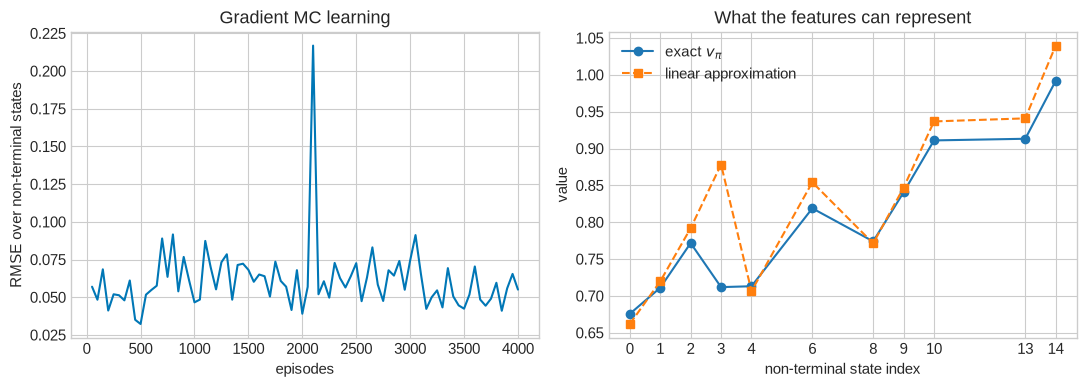

In [8]:
def train_gradient_mc(env, episodes=4000, alpha=0.02, gamma=GAMMA, seed=SEED):
    local_rng = np.random.default_rng(seed)
    w = np.zeros(X_frozen.shape[1])
    rmse_history = []

    for episode_idx in range(episodes):
        trajectory = sample_episode(env, local_rng)
        G = 0.0
        # Moving backward makes the return calculation O(T).
        for state, action, reward, next_state, done in reversed(trajectory):
            G = reward + gamma * G
            x = features(state)
            w += alpha * (G - w @ x) * x

        if (episode_idx + 1) % 50 == 0:
            error = X_frozen @ w - true_v
            rmse_history.append(np.sqrt(np.mean(error[nonterminal_mask] ** 2)))

    return w, np.asarray(rmse_history)

w_mc, mc_rmse = train_gradient_mc(env)
v_mc = X_frozen @ w_mc

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.arange(1, len(mc_rmse)+1) * 50, mc_rmse, color="#0077b6")
axes[0].set(xlabel="episodes", ylabel="RMSE over non-terminal states", title="Gradient MC learning")

x = np.flatnonzero(nonterminal_mask)
axes[1].plot(x, true_v[x], "o-", label="exact $v_\\pi$")
axes[1].plot(x, v_mc[x], "s--", label="linear approximation")
axes[1].set(xlabel="non-terminal state index", ylabel="value", xticks=x,
            title="What the features can represent")
axes[1].legend()
plt.tight_layout()
plt.show()

### Interpret the figure

The curve need not reach zero error. We are projecting the true value function onto a six-dimensional feature space. This creates **approximation error**, even with unlimited data. The RMSE and value plot use non-terminal states: terminal values are defined as zero and are never prediction-update inputs in our episode loop.

Monte Carlo targets are:

- **unbiased** samples of the return under the policy;
- often **high variance**, because every later random event changes $G_t$;
- delayed until the episode ends.

**Discussion:** would adding more episodes fix poor features? Why or why not?

## 5. Semi-gradient TD(0)

TD(0) uses the one-step target

$$U_t=R_{t+1}+\gamma\hat v(S_{t+1},\mathbf w_t).$$

The target now depends on the same weights being updated. In the **semi-gradient** update, we treat that target as fixed and differentiate only the current-state prediction:

$$\delta_t=R_{t+1}+\gamma\hat v(S_{t+1},\mathbf w_t)-\hat v(S_t,\mathbf w_t),$$

$$\mathbf w_{t+1}=\mathbf w_t+\alpha\delta_t\nabla_{\mathbf w}\hat v(S_t,\mathbf w_t).$$

For a terminal transition, the next-state value is defined as zero. TD can update after every transition; it does not wait for the episode to finish.

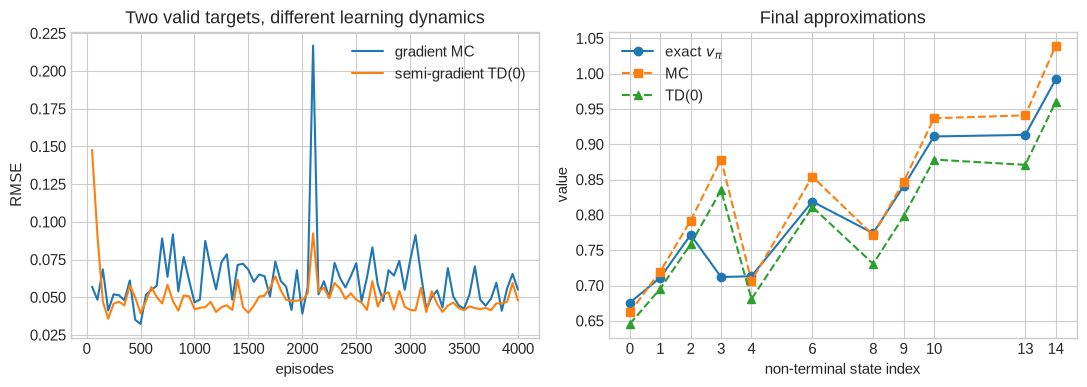

In [9]:
def train_semi_gradient_td(env, episodes=4000, alpha=0.015, gamma=GAMMA, seed=SEED):
    local_rng = np.random.default_rng(seed)
    w = np.zeros(X_frozen.shape[1])
    rmse_history = []

    for episode_idx in range(episodes):
        state, _ = env.reset(seed=int(local_rng.integers(1_000_000)))
        done = False
        while not done:
            action = local_rng.choice(N_ACTIONS, p=policy_probabilities(state))
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            prediction = w @ features(state)
            next_value = 0.0 if done else w @ features(next_state)
            td_error = reward + gamma * next_value - prediction
            w += alpha * td_error * features(state)
            state = next_state

        if (episode_idx + 1) % 50 == 0:
            error = X_frozen @ w - true_v
            rmse_history.append(np.sqrt(np.mean(error[nonterminal_mask] ** 2)))

    return w, np.asarray(rmse_history)

w_td, td_rmse = train_semi_gradient_td(env)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
episode_axis = np.arange(1, len(mc_rmse)+1) * 50
axes[0].plot(episode_axis, mc_rmse, label="gradient MC")
axes[0].plot(episode_axis, td_rmse, label="semi-gradient TD(0)")
axes[0].set(xlabel="episodes", ylabel="RMSE", title="Two valid targets, different learning dynamics")
axes[0].legend()

state_indices = np.flatnonzero(nonterminal_mask)
axes[1].plot(state_indices, true_v[state_indices], "o-", label="exact $v_\\pi$")
axes[1].plot(state_indices, (X_frozen @ w_mc)[state_indices], "s--", label="MC")
axes[1].plot(state_indices, (X_frozen @ w_td)[state_indices], "^--", label="TD(0)")
axes[1].set(xlabel="non-terminal state index", ylabel="value", xticks=state_indices,
            title="Final approximations")
axes[1].legend()
plt.tight_layout()
plt.show()

### MC, TD, and $n$-step targets form a spectrum

The $n$-step return is

$$G_t^{(n)}=R_{t+1}+\gamma R_{t+2}+\cdots+\gamma^{n-1}R_{t+n}+\gamma^n\hat v(S_{t+n},\mathbf w).$$

- $n=1$ gives TD(0): more bootstrapping, usually lower variance, but a biased target.
- $n$ equal to the remaining episode length gives Monte Carlo: no bootstrapping, usually higher variance.
- Intermediate $n$ values trade off these effects.

The purpose of bootstrapping is not to claim that the current estimate is correct. It uses the current estimate as a temporary target and repeatedly corrects it as new evidence arrives.

## 6. From prediction to control

Policy evaluation estimates $v_\pi$. Control requires action values:

$$q_\pi(s,a)\approx\hat q(s,a,\mathbf w).$$

The update template is unchanged:

$$\mathbf w\leftarrow\mathbf w+\alpha[U_t-\hat q(S_t,A_t,\mathbf w)]\nabla_{\mathbf w}\hat q(S_t,A_t,\mathbf w).$$

Different control algorithms choose different targets:

| Method | Target |
|---|---|
| SARSA | $R_{t+1}+\gamma\hat q(S_{t+1},A_{t+1},\mathbf w)$ |
| Expected SARSA | $R_{t+1}+\gamma\sum_a\pi(a\mid S_{t+1})\hat q(S_{t+1},a,\mathbf w)$ |
| Q-learning | $R_{t+1}+\gamma\max_a\hat q(S_{t+1},a,\mathbf w)$ |

We will use **semi-gradient SARSA**, an on-policy method, on MountainCar. Its two continuous state variables are position and velocity, so a table would require arbitrary discretisation.

In [10]:
mc_env = gym.make("MountainCar-v0")
print("Observation bounds:")
print("  low :", mc_env.observation_space.low)
print("  high:", mc_env.observation_space.high)
print("Actions: 0 = push left, 1 = coast, 2 = push right")

Observation bounds:
  low : [-1.2  -0.07]
  high: [0.6  0.07]
Actions: 0 = push left, 1 = coast, 2 = push right


### Tile coding: sparse linear features

Tile coding overlays several slightly shifted grids. A state activates one tile in each grid. Nearby states share some, but not all, active features.

This gives:

- local generalisation rather than one global straight line;
- sparse, fast updates;
- a model that remains linear in the weights.

For each action, $\hat q(s,a,\mathbf w)$ is the sum of the active tile weights.

In [11]:
class TileCoder:
    def __init__(self, low, high, num_tilings=8, tiles_per_dim=8):
        self.low = np.asarray(low, dtype=float)
        self.high = np.asarray(high, dtype=float)
        self.num_tilings = num_tilings
        self.tiles_per_dim = tiles_per_dim
        self.tile_width = (self.high - self.low) / (tiles_per_dim - 1)
        self.n_features = num_tilings * tiles_per_dim ** 2

    def active_indices(self, state):
        state = np.asarray(state, dtype=float)
        indices = []
        for tiling in range(self.num_tilings):
            # Different offset in each dimension for each tiling.
            fractions = np.array([tiling, 2 * tiling + 1]) % self.num_tilings
            offset = fractions / self.num_tilings * self.tile_width
            coordinates = np.floor((state - self.low + offset) / self.tile_width).astype(int)
            coordinates = np.clip(coordinates, 0, self.tiles_per_dim - 1)
            flat = coordinates[0] * self.tiles_per_dim + coordinates[1]
            indices.append(tiling * self.tiles_per_dim**2 + flat)
        return np.asarray(indices, dtype=int)

tile_coder = TileCoder(mc_env.observation_space.low, mc_env.observation_space.high)
example_state = np.array([-0.5, 0.01])
print("Number of possible features:", tile_coder.n_features)
print("Number active in one state:", len(tile_coder.active_indices(example_state)))
print("Active indices for", example_state, ":", tile_coder.active_indices(example_state))

Number of possible features: 512
Number active in one state: 8
Active indices for [-0.5   0.01] : [ 20  84 148 220 284 348 412 476]


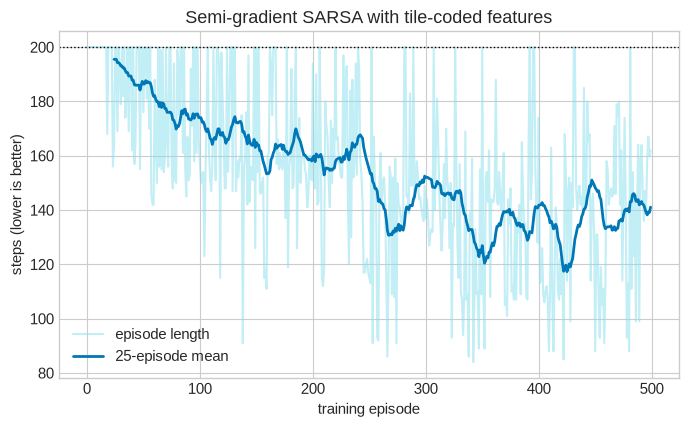

Mean length, first 50 episodes: 191.5
Mean length, last 50 episodes : 138.5


In [12]:
def q_value(weights, state, action, coder):
    return weights[action, coder.active_indices(state)].sum()

def epsilon_greedy(weights, state, coder, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(weights.shape[0]))
    values = np.array([q_value(weights, state, a, coder) for a in range(weights.shape[0])])
    best = np.flatnonzero(values == values.max())
    return int(rng.choice(best))

def train_sarsa(env, coder, episodes=500, alpha=0.5, gamma=1.0, seed=SEED):
    local_rng = np.random.default_rng(seed)
    weights = np.zeros((env.action_space.n, coder.n_features))
    episode_lengths = []

    for episode_idx in range(episodes):
        state, _ = env.reset(seed=int(local_rng.integers(1_000_000)))
        epsilon = max(0.01, 0.10 * (1 - episode_idx / episodes))
        action = epsilon_greedy(weights, state, coder, epsilon, local_rng)

        for step in range(1, 201):
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            current_q = q_value(weights, state, action, coder)

            if done:
                target = reward
                next_action = None
            else:
                next_action = epsilon_greedy(weights, next_state, coder, epsilon, local_rng)
                target = reward + gamma * q_value(weights, next_state, next_action, coder)

            td_error = target - current_q
            active = coder.active_indices(state)
            weights[action, active] += (alpha / coder.num_tilings) * td_error

            if done:
                episode_lengths.append(step)
                break
            state, action = next_state, next_action

    return weights, np.asarray(episode_lengths)

weights, episode_lengths = train_sarsa(mc_env, tile_coder)

window = 25
moving_average = np.convolve(episode_lengths, np.ones(window)/window, mode="valid")
fig, ax = plt.subplots()
ax.plot(episode_lengths, color="#90e0ef", alpha=.55, label="episode length")
ax.plot(np.arange(window-1, len(episode_lengths)), moving_average,
        color="#0077b6", lw=2, label=f"{window}-episode mean")
ax.axhline(200, color="black", ls=":", lw=1)
ax.set(xlabel="training episode", ylabel="steps (lower is better)",
       title="Semi-gradient SARSA with tile-coded features")
ax.legend()
plt.show()

print("Mean length, first 50 episodes:", episode_lengths[:50].mean().round(1))
print("Mean length, last 50 episodes :", episode_lengths[-50:].mean().round(1))

### Visualise the learned approximation

The next figure plots $\max_a\hat q(s,a,\mathbf w)$. The surface is not stored as a table: every point is computed from the shared tile weights.

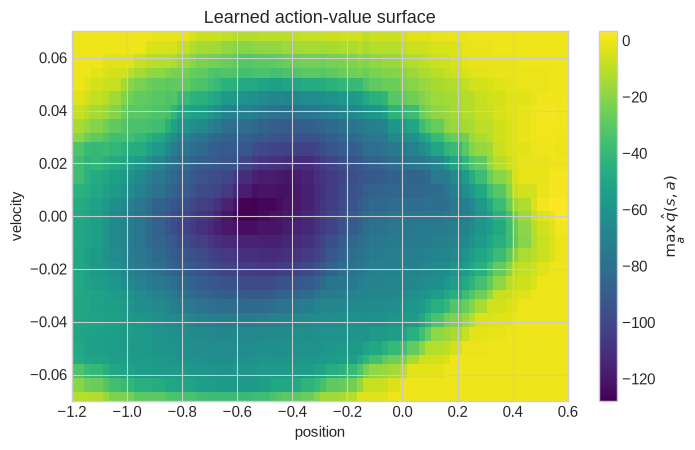

In [13]:
positions = np.linspace(-1.2, 0.6, 80)
velocities = np.linspace(-0.07, 0.07, 80)
value_surface = np.empty((len(velocities), len(positions)))

for i, velocity in enumerate(velocities):
    for j, position in enumerate(positions):
        state = np.array([position, velocity])
        value_surface[i, j] = max(q_value(weights, state, a, tile_coder) for a in range(3))

fig, ax = plt.subplots(figsize=(8, 4.8))
image = ax.imshow(value_surface, origin="lower", aspect="auto",
                  extent=[positions.min(), positions.max(), velocities.min(), velocities.max()],
                  cmap="viridis")
fig.colorbar(image, ax=ax, label=r"$\max_a\hat q(s,a)$")
ax.set(xlabel="position", ylabel="velocity", title="Learned action-value surface")
plt.show()

### Animation: greedy control after training

The car is underpowered. A useful policy first moves away from the goal to gain momentum, then climbs the right hill.

In [14]:
def greedy_mountaincar_trajectory(env, weights, coder, seed=123):
    local_rng = np.random.default_rng(seed)
    state, _ = env.reset(seed=seed)
    trajectory = [state.copy()]
    for _ in range(200):
        action = epsilon_greedy(weights, state, coder, epsilon=0.0, rng=local_rng)
        state, reward, terminated, truncated, _ = env.step(action)
        trajectory.append(state.copy())
        if terminated or truncated:
            break
    return np.asarray(trajectory)

mc_trajectory = greedy_mountaincar_trajectory(mc_env, weights, tile_coder)
print("Greedy episode length:", len(mc_trajectory) - 1)

def animate_mountaincar(trajectory):
    # Keep the animation lightweight by displaying at most about 70 frames.
    stride = max(1, len(trajectory) // 70)
    frames = trajectory[::stride]
    hill_x = np.linspace(-1.2, 0.6, 500)
    hill_y = np.sin(3 * hill_x) * 0.45 + 0.55

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(hill_x, hill_y, color="#386641", lw=3)
    ax.axvline(0.5, color="#d00000", ls="--", label="goal")
    car, = ax.plot([], [], "o", ms=14, color="#023047", mec="white", mew=2)
    velocity_text = ax.text(0.02, 0.92, "", transform=ax.transAxes)
    ax.set(xlim=(-1.2, 0.6), ylim=(0, 1.1), xlabel="position", yticks=[],
           title="MountainCar: greedy tile-coded SARSA policy")
    ax.legend(loc="upper left")

    def update(frame):
        position, velocity = frames[frame]
        car.set_data([position], [np.sin(3 * position) * 0.45 + 0.58])
        velocity_text.set_text(f"velocity = {velocity:+.3f}")
        return car, velocity_text

    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=70,
                                   blit=True, repeat=True)
    plt.close(fig)
    return anim

display(HTML(animate_mountaincar(mc_trajectory).to_jshtml()))

Greedy episode length: 163


## 7. Nonlinear value approximation

A neural network replaces the linear map with $\hat v(s,\mathbf w)=f(\mathbf x(s);\mathbf w)$. The update principle is still:

1. predict $\hat v(S_t,\mathbf w)$;
2. construct an MC, TD, or $n$-step target $U_t$;
3. compute a squared-error loss;
4. backpropagate through the prediction;
5. update all weights and biases.

For a TD target, modern autodifferentiation code must stop gradients through the target during a semi-gradient update:

```python
prediction = value_network(state)
with no_gradient():
    target = reward + gamma * value_network(next_state) * (1 - done)
loss = 0.5 * (target - prediction) ** 2
```

Neural networks are more expressive, but the objective is generally non-convex and convergence guarantees are limited. Practical stabilisers include careful input scaling, conservative learning rates, gradient clipping, replay sampling, target networks, and monitoring prediction magnitudes.

## 8. The deadly triad

Instability and divergence are especially likely when all three are combined:

| Component | Why we still want it |
|---|---|
| Function approximation | scales and generalises |
| Bootstrapping | updates before the full return is known |
| Off-policy learning | reuses data from another policy or a replay buffer |

None is inherently wrong. The risk comes from their interaction: a bootstrapped target can contain approximation errors; off-policy data can emphasise a different state distribution; shared parameters can then propagate those errors to many predictions.

Our MountainCar demonstration used function approximation and bootstrapping, but SARSA learned **on-policy**. Q-learning would add the third component because the behaviour is exploratory while its target uses the greedy action.